# 📈 Stock Market Chart CNN — Buy / Sell Prediction
### Deep Learning | Image Classification | Binary (Buy = 0 , Sell = 1)
---
**Dataset folder structure expected:**
```
train/
    buy/   ← stock chart images labelled BUY
    sell/  ← stock chart images labelled SELL
test/
    buy/
    sell/
```

In [ ]:
#wwwwwwwww


## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
import cv2

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2 — Set Paths & Parameters

In [8]:
# ✏️  Change these paths to where your dataset is saved
TRAIN_DIR = "Train"   # folder containing buy/ and sell/ subfolders
TEST_DIR  = "Test"    # folder containing buy/ and sell/ subfolders

IMG_SIZE   = 64       # resize every chart to 64x64 pixels
BATCH_SIZE = 32
EPOCHS     = 20
CLASSES    = ['Down', 'Up']   # class names must match folder names

print(f"Train dir : {TRAIN_DIR}")
print(f"Test  dir : {TEST_DIR}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")

Train dir : Train
Test  dir : Test
Image size: 64x64


## Step 3 — Load Images from Folders

In [9]:
def load_images(data_dir, img_size, classes):
    """Read all images from class sub-folders, resize, and return X, y arrays."""
    X = []
    y = []
    for label_idx, class_name in enumerate(classes):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.exists(class_path):
            print(f"⚠️  Folder not found: {class_path}")
            continue
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)
            try:
                img = cv2.imread(file_path)
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label_idx)
            except Exception as e:
                print(f"Skipped {file_name}: {e}")
    return np.array(X), np.array(y)

print("Loading training images...")
X_train_raw, y_train = load_images(TRAIN_DIR, IMG_SIZE, CLASSES)

print("Loading test images...")
X_test_raw, y_test = load_images(TEST_DIR, IMG_SIZE, CLASSES)

print(f"\nTraining samples : {X_train_raw.shape[0]}")
print(f"Test     samples : {X_test_raw.shape[0]}")
print(f"Image shape      : {X_train_raw.shape[1:]}")

Loading training images...
Loading test images...
Skipped .ipynb_checkpoints: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'cv::resize'


Training samples : 1433
Test     samples : 351
Image shape      : (64, 64, 3)


## Step 4 — Explore the Data

Training class distribution: {'Down': np.int64(624), 'Up': np.int64(809)}


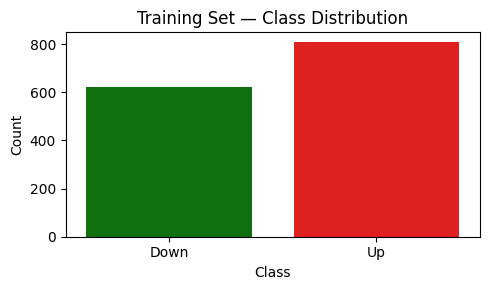

In [10]:
# Class distribution — training set
unique, counts = np.unique(y_train, return_counts=True)
class_dist = dict(zip([CLASSES[i] for i in unique], counts))
print("Training class distribution:", class_dist)

# Bar chart
plt.figure(figsize=(5, 3))
sns.barplot(x=list(class_dist.keys()), y=list(class_dist.values()), palette=['green','red'])
plt.title('Training Set — Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

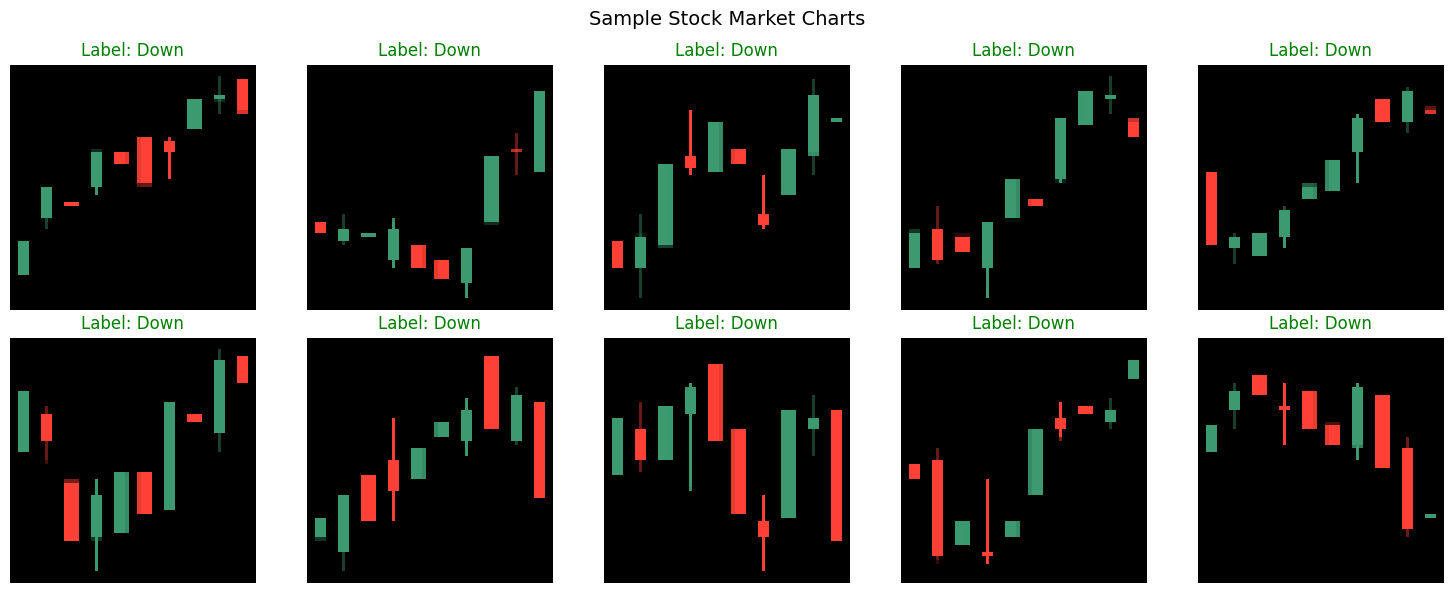

In [11]:
# Preview 10 sample charts
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(X_train_raw):
        ax.imshow(X_train_raw[i])
        ax.set_title(f'Label: {CLASSES[y_train[i]]}', color='green' if y_train[i]==0 else 'red')
        ax.axis('off')
plt.suptitle('Sample Stock Market Charts', fontsize=14)
plt.tight_layout()
plt.show()

## Step 5 — Preprocess (Normalize + One-Hot Encode)

In [12]:
# Normalize pixel values to [0, 1]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# One-hot encode labels  (buy → [1,0] , sell → [0,1])
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat  = to_categorical(y_test,  num_classes=2)

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train_cat shape : {y_train_cat.shape}")
print(f"Sample label (first 3): {y_train_cat[:3]}")

X_train shape : (1433, 64, 64, 3)
X_test  shape : (351, 64, 64, 3)
y_train_cat shape : (1433, 2)
Sample label (first 3): [[1. 0.]
 [1. 0.]
 [1. 0.]]


## Step 6 — Data Augmentation (Helps Reach 85%+ Accuracy)

In [13]:
# ImageDataGenerator creates augmented versions on-the-fly during training
train_datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation on test — just rescaling (already done above)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE)
test_generator  = test_datagen.flow(X_test, y_test_cat, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Data augmentation configured!")

✅ Data augmentation configured!


## Step 7 — Build the CNN Model

In [14]:
cnn = Sequential([

    # ── Block 1 ──────────────────────────────
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),          # stabilises training
    MaxPooling2D(pool_size=(2, 2)),

    # ── Block 2 ──────────────────────────────
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # ── Block 3 ──────────────────────────────
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # ── Fully Connected Head ─────────────────
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),                  # prevents overfitting
    Dense(128, activation='relu'),
    Dropout(0.3),

    # ── Output Layer ─────────────────────────
    Dense(2, activation='softmax') # 2 classes: buy / sell
])

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,307,202 (4.99 MB)

 Trainable params: 1,306,754 (4.98 MB)

 Non-trainable params: 448 (1.75 KB)

## Step 8 — Compile the Model

In [15]:
cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled!")

✅ Model compiled!


## Step 9 — Callbacks (Early Stopping + LR Reducer)

In [16]:
# EarlyStopping — stops training if val_accuracy stops improving
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau — lowers learning rate if stuck
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

print("✅ Callbacks set!")

✅ Callbacks set!


## Step 10 — Train the Model

In [17]:
history = cnn.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=[early_stop, lr_reducer],
    verbose=1
)

print("\n✅ Training complete!")

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.5192 - loss: 1.4984 - val_accuracy: 0.4501 - val_loss: 0.7725 - learning_rate: 0.0010
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.5052 - loss: 0.9568 - val_accuracy: 0.5527 - val_loss: 0.7937 - learning_rate: 0.0010
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.5164 - loss: 0.8042 - val_accuracy: 0.5527 - val_loss: 1.1667 - learning_rate: 0.0010
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5204 - loss: 0.7973
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - accuracy: 0.5150 - loss: 0.7723 - val_accuracy: 0.5527 - val_loss: 1.8547 - learning_rate: 0.0010
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.5311 - loss: 0.7178 - val_accuracy: 0.5527 - val_loss: 1.9042 - learning_rate: 5.0000e-04
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.5269 - loss: 0.7122 - va

## Step 11 — Evaluate on Test Set

In [18]:
test_loss, test_accuracy = cnn.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

if test_accuracy >= 0.85:
    print("🎉 Target accuracy of 85%+ ACHIEVED!")
else:
    print("⚠️  Below 85% — try more epochs or add more training images.")

Test Loss     : 0.7937
Test Accuracy : 55.27%
⚠️  Below 85% — try more epochs or add more training images.


## Step 12 — Training History Plots

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].axhline(y=0.85, color='green', linestyle='--', label='85% Target')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='red')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Step 13 — Confusion Matrix & Classification Report

In [ ]:
# Predictions on test set
y_pred_prob = cnn.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Overall Accuracy: {acc * 100:.2f}%")

In [ ]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — CNN Stock Chart Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Step 14 — Save the Model (.keras file)

In [ ]:
MODEL_PATH = 'stock_chart_cnn.keras'
cnn.save(MODEL_PATH)
print(f"✅ Model saved as '{MODEL_PATH}'")

## Step 15 — Predict on a New Chart Image (Upload Your Own)

In [ ]:
from tensorflow.keras.models import load_model

def predict_chart(image_path, model_path='stock_chart_cnn.keras', img_size=64):
    """
    Upload any stock chart image and get a BUY / SELL prediction.

    Parameters:
        image_path : str  — path to the .jpg / .png chart image
        model_path : str  — path to saved .keras model
        img_size   : int  — must match training IMG_SIZE (default 64)
    """
    # Load model
    model = load_model(model_path)

    # Load & preprocess image
    img = cv2.imread(image_path)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_array = img.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # shape (1, 64, 64, 3)

    # Predict
    prediction = model.predict(img_array, verbose=0)
    class_idx   = np.argmax(prediction)
    confidence  = prediction[0][class_idx] * 100
    label       = ['BUY', 'SELL'][class_idx]
    color       = 'green' if label == 'BUY' else 'red'

    # Show result
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f'Prediction: {label}  ({confidence:.1f}% confidence)',
              fontsize=14, color=color, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Prediction  : {label}")
    print(f"🔢 Confidence  : {confidence:.2f}%")
    print(f"📈 Buy  prob   : {prediction[0][0]*100:.2f}%")
    print(f"📉 Sell prob   : {prediction[0][1]*100:.2f}%")

    return label, confidence


# ✏️  Change 'your_chart.jpg' to your actual image path
# predict_chart('your_chart.jpg')
print("✅ predict_chart() function is ready!")
print("Usage: predict_chart('path/to/your/chart.jpg')")

## Step 16 — Quick Test on a Few Test Images

In [ ]:
# Visualise 8 test predictions vs ground truth
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
indices = np.random.choice(len(X_test), 8, replace=False)

for ax, idx in zip(axes.flat, indices):
    img = X_test[idx]
    true_label = CLASSES[y_test[idx]]

    prob = cnn.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_label = CLASSES[np.argmax(prob)]
    confidence = np.max(prob) * 100

    correct = (true_label == pred_label)
    border_color = 'green' if correct else 'red'

    ax.imshow(img)
    ax.set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color=border_color, fontsize=9
    )
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)

plt.suptitle('CNN Predictions on Test Charts  (Green = Correct | Red = Wrong)',
             fontsize=13)
plt.tight_layout()
plt.show()

---
## ✅ Summary

| Step | What we did |
|------|-------------|
| 1 | Imported all libraries |
| 2 | Set paths and hyperparameters |
| 3 | Loaded images from buy/sell folders using OpenCV |
| 4 | Explored data (class distribution + sample images) |
| 5 | Normalized pixels + one-hot encoded labels |
| 6 | Applied data augmentation to boost accuracy |
| 7 | Built 3-block CNN with BatchNorm + Dropout |
| 8 | Compiled with Adam optimizer |
| 9 | Added EarlyStopping + ReduceLROnPlateau callbacks |
| 10 | Trained the model |
| 11 | Evaluated — target **85%+ accuracy** |
| 12 | Plotted accuracy and loss curves |
| 13 | Confusion matrix + classification report |
| 14 | Saved model as **stock_chart_cnn.keras** |
| 15 | `predict_chart()` function for uploading new images |
| 16 | Visual test on random test images |